# Homework 10


**Concepts covered:**

pandas `DataFrame`s: initialization,  descriptive statistics, line plot, scatter plot, histogram, column-wise operations, row-wise operations.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

While we encourage you to use AI to generate practice problems, **we recommend against using generative AI in the strongest terms** to solve any part of this assignment. The goal of this assignment is for you to learn these concepts, and while using AI may help you obtain solutions to these problems, you will cheat yourself out of the learning that comes from working through the problems yourself.

**Sample Output:**

For each problem description, a sample output has been included to show what the expected output should be.
Some functions have test cases provided for you to test with, so no sample output has been included for those.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [1]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.close("all")

# access to data file(s); update to week-10
df_stock_prices = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/SPY.csv")
df_stock_prices.index = pd.to_datetime(df_stock_prices["date"], unit='s')

df_weather = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/02215_weather.csv")
df_weather.index = pd.to_datetime(df_weather["datetime"], format="%m/%d/%y")


df_econ_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/annual_data.csv")
df_econ_data.index = df_econ_data["Year"]



**Note: This will be partially manually graded, so please allow some time before getting your full grade.**

**Review Problem 1**

**Concept:** *matplotlib, scatter plot*


**Task:**

Create a scatter plot that produces a spiral/cyclone pattern.

* Generate radius values that gradually increase
* Generate angle values that rotate around the origin
* Compute:
  * x = radius × cos(angle)
  * y = radius × sin(angle)
* Plot the points using plt.scatter()
* Add a title

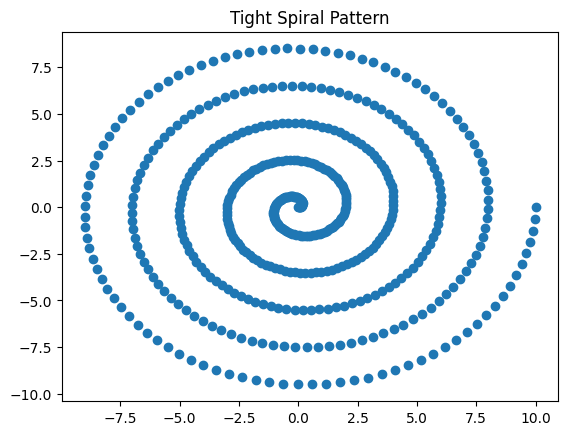

In [58]:
# Your Solution
def spiral_plot():
    '''Creates a spiral plot'''
    num_points = 500
    angle = np.linspace(0, 10 * np.pi, num_points)
    radius = np.linspace(0, 10, num_points)
    
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    
    plt.figure()
    plt.scatter(x, y)
    plt.title('Tight Spiral Pattern')
    plt.show()

spiral_plot()


**Review Problem 2**

**Concept:** *reading CSV data, matplotlib, line graph*

**Task:**

Write a function `read_and_plot_column(filename, column_name)` that:
* Opens a CSV file (do **not** use pandas)
* Extracts the values from the specified column
* Casts all values to `float`
* Plots the values using `plt.plot()`
* Adds a title
* Displays the plot

In [3]:
# Your Solution

def read_and_plot_column(filename, column_name):
    '''Reads a CSV file and extracts the data associated with a column_name and creates a line graph'''
    with open(filename) as f:
        headers = f.readline().strip().split(',')
        # print(headers)
        col_idx = headers.index(column_name)
        # print(headers)
        values = []
        for line in f:
            # print(line)
            line = line.split(',')
            # print(line)
            value = float(line[col_idx].strip())
            # print(value)
            values.append(value)
    plt.figure()
    plt.plot(values)
    plt.title(f'{column_name}: Linegraph')
    plt.show()

            
        
        

Test case for problem 2

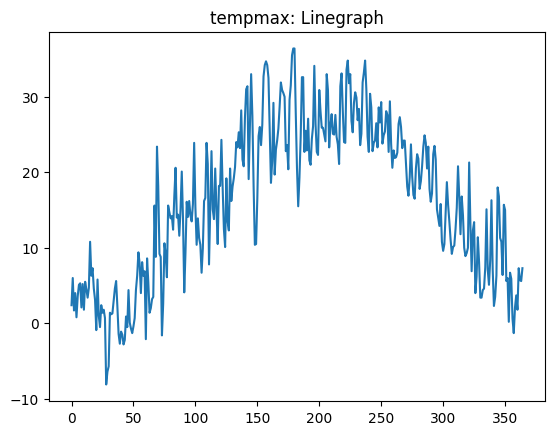

In [4]:
# test case:
read_and_plot_column("02215_weather.csv", "tempmax")


**Problem 3**

**Concept:** *Examining Data*


**Task:**

Using `df_weather`:
* Print the first 5 rows
* Print the last 5 rows

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_weather_head`
* `df_weather_tail`

**Sample Output:**

If the following was your dataframe:

```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

```

The following will be your output:

```
FIRST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

LAST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```


In [65]:
# Your Solution
df_weather_head = df_weather.head(5)
print(df_weather_head)
df_weather_tail = df_weather.tail(5)
print(df_weather_tail)

           datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
datetime                                                                  
2021-01-01   1/1/21      2.4     -2.4   0.5           2.3          -6.8   
2021-01-02   1/2/21      6.0      0.1   3.9           3.8          -5.1   
2021-01-03   1/3/21      1.7     -1.4   0.1          -1.7          -5.7   
2021-01-04   1/4/21      4.0     -0.6   1.0          -0.3          -5.7   
2021-01-05   1/5/21      0.8     -1.0  -0.3          -3.9          -6.1   

            feelslike  dew  humidity  precip  ...              sunrise  \
datetime                                      ...                        
2021-01-01       -1.9 -5.4      65.0   0.897  ...  2021-01-01T07:13:45   
2021-01-02       -0.4  1.6      85.7  12.092  ...  2021-01-02T07:13:48   
2021-01-03       -3.8 -3.0      79.7   0.794  ...  2021-01-03T07:13:49   
2021-01-04       -3.5 -2.3      78.9   0.000  ...  2021-01-04T07:13:47   
2021-01-05       -4.8 -2.7    

**Problem 4**

**Concept:** *Accessing `DataFrame` columns*


**Task:**

Using `df_weather`:
* Print all column names
* Create a list of columns that contain the substring `"temp"`
* Create a new DataFrame using only those columns
* Print the result

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_temp_cols`

**Sample Output:**

If the following were your column names and dataframe:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```

And you selected the columns that matched your condition, the following could be your output:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color
P1   shirt   blue
P2   pants  black
P3     hat    red
P4  jacket  green
P5   shoes  white
```



In [ ]:
# Your Solution

print(df_weather.columns)
temp_columns = [col for col in df_weather.columns if 'temp' in col]
df_weather_temp_cols = df_weather[temp_columns]
print(df_weather_temp_cols.head(5))






Index(['datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations',
       'sunrise_hours', 'sunset_hours', 'range'],
      dtype='object')
            tempmax  tempmin  temp
datetime                          
2021-01-01      2.4     -2.4   0.5
2021-01-02      6.0      0.1   3.9
2021-01-03      1.7     -1.4   0.1
2021-01-04      4.0     -0.6   1.0
2021-01-05      0.8     -1.0  -0.3


**Problem 5**

**Concept:** *Descriptive Statistics*


**Task:**

Using `df_weather`:

* Display descriptive statistics for all columns

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_descriptive_statistics`

**Sample Output:**

If the following was your dataframe:
```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```
The following will be your output:
```
DESCRIPTIVE STATISTICS:
           price
count   5.000000
mean   36.000000
std    19.235384
min    15.000000
25%    20.000000
50%    35.000000
75%    50.000000
max    60.000000

```



In [7]:
# Your Solution
df_weather_descriptive_statistics = df_weather.describe()
print(df_weather_descriptive_statistics)

          tempmax     tempmin        temp  feelslikemax  feelslikemin  \
count  365.000000  365.000000  365.000000    365.000000    365.000000   
mean    16.215616    8.451781   12.292055     15.490411      6.158904   
std     10.236355    9.420414    9.609977     11.918353     11.772183   
min     -8.100000  -14.300000  -10.400000    -16.700000    -25.600000   
25%      7.100000    0.500000    3.900000      5.300000     -4.100000   
50%     16.600000    8.900000   12.300000     16.600000      6.700000   
75%     24.200000   17.100000   20.400000     24.200000     17.100000   
max     36.400000   26.200000   31.200000     40.600000     26.200000   

        feelslike         dew    humidity      precip  precipprob  ...  \
count  365.000000  365.000000  365.000000  365.000000  365.000000  ...   
mean    10.823288    5.084384   64.213151    3.654545   44.657534  ...   
std     11.611922   10.629004   15.479875    9.119694   49.782003  ...   
min    -20.300000  -21.000000   26.000000    0

**Problem 6**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `tempmax` column
* Add a title
* Display the plot

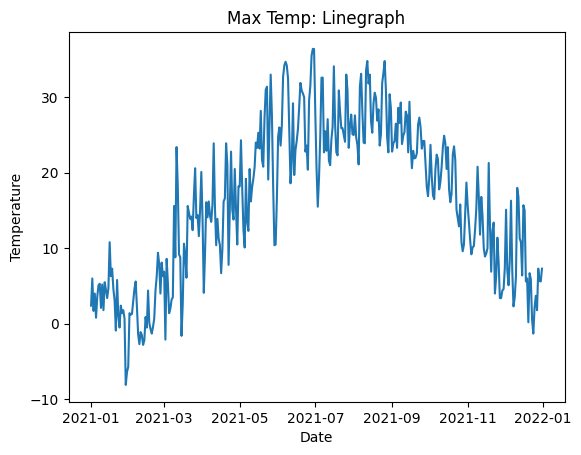

In [8]:
# Your Solution

tempmax_data = df_weather['tempmax']

plt.plot(tempmax_data)
plt.title('Max Temp: Linegraph')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

**Problem 7**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `precip` column
* Add a title
* Display the plot


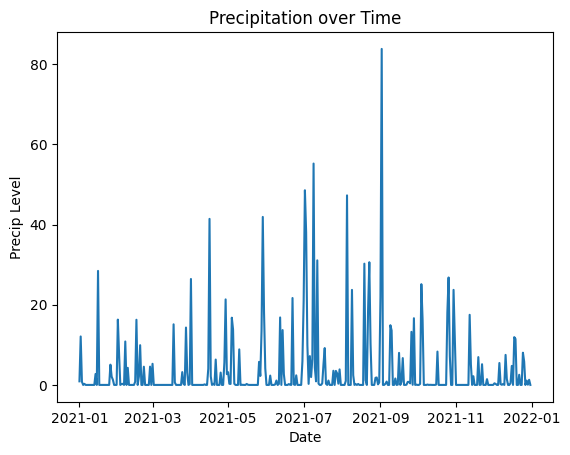

In [9]:
# Your Solution

precip_data = df_weather['precip']

plt.plot(precip_data)
plt.title('Precipitation over Time')
plt.xlabel('Date')
plt.ylabel('Precip Level')
plt.show()


**Problem 8**

**Concept:** *histogram*


**Task:**

Using `df_weather`:
* Create a histogram of the `feelslike` column
* Use 25 bins
* Add a title
* Display the plot


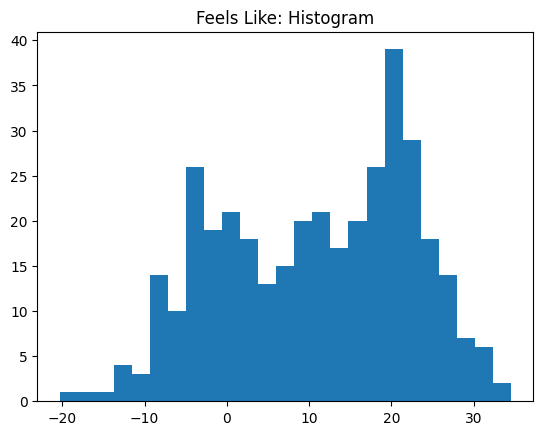

In [10]:
# Your Solution

feelslike_data = df_weather['feelslike']
plt.hist(feelslike_data, bins = 25)
plt.title('Feels Like: Histogram')
plt.show()



**Problem 9**

**Concept:** *pie chart*


**Task:**

* Print value counts of `df_weather['conditions']`
* Create a pie chart of the values
* Make sure to include labels
* Print value counts of `df_econ_data['PresidentParty']`
* Create a pie chart of the values
* Make sure to include labels

**Sample Output:**

If one of your columns contained the following values:
```
blue, black, red, green, white
```
The following could be your printed value counts:
```
blue     1
black    1
red      1
green    1
white    1
Name: color, dtype: int64
```
If another column contained the following values:
```
summer, winter, summer, spring, winter
```
The following could be your printed value counts:
```
summer    2
winter    2
spring    1
Name: season, dtype: int64
```

conditions
Partially cloudy                181
Rain, Partially cloudy           89
Rain, Overcast                   47
Snow, Rain, Overcast             18
Clear                            12
Overcast                          9
Snow, Rain, Partially cloudy      7
Snow, Overcast                    1
Snow, Partially cloudy            1
Name: count, dtype: int64


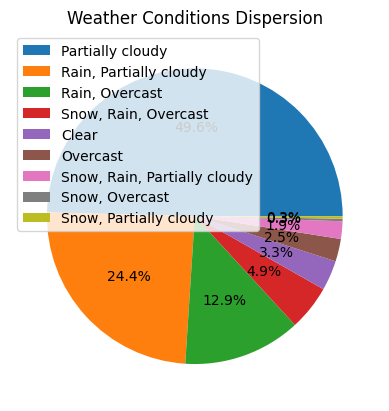

PresidentParty
Democrat      52
Republican    44
Name: count, dtype: int64


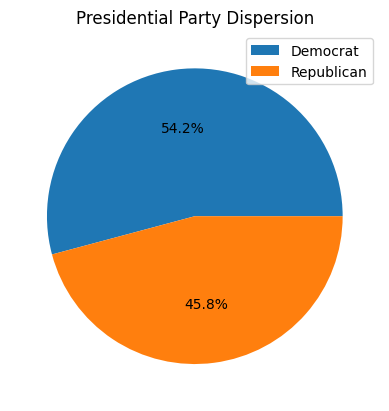

In [11]:
# Your Solution
conditions_data = df_weather['conditions'].value_counts()
print(conditions_data)
conditions_idx = conditions_data.index
plt.pie(conditions_data, autopct = '%1.1f%%')
plt.title('Weather Conditions Dispersion')
plt.legend(conditions_idx, loc = 'best')
plt.show()

pres_party_data = df_econ_data['PresidentParty'].value_counts()
print(pres_party_data)
pres_party_idx = pres_party_data.index
plt.pie(pres_party_data, autopct = '%1.1f%%')
plt.title('Presidential Party Dispersion')
plt.legend(pres_party_idx)
plt.show()






**Problem 10**

**Concept:** *creating new column data, extracting columns, plotting*


**Task:**

Using `df_weather`:
* Write a helper function to extract time (in hours) from a datetime string and convert it to decimal hours (float)
* Convert time using:

    `hours + (minutes / 60) + (seconds / 3600)`
* Create a new DataFrame with the same index as `df_weather`
* Add the following columns:
  * `sunrise` (converted to float)
  * `sunset` (converted to float)
  * `tempmin` (copied directly from `df_weather`)
* Plot all columns together using `.plot()`


**Sample Output:**

This is similar to how your new dataframe should look before plotting:

```
   start_time  end_time  price
P1       8.25     17.50     20
P2       8.50     17.75     35
P3       9.00     18.00     15
P4       9.25     18.25     60
P5       9.50     18.50     50
```

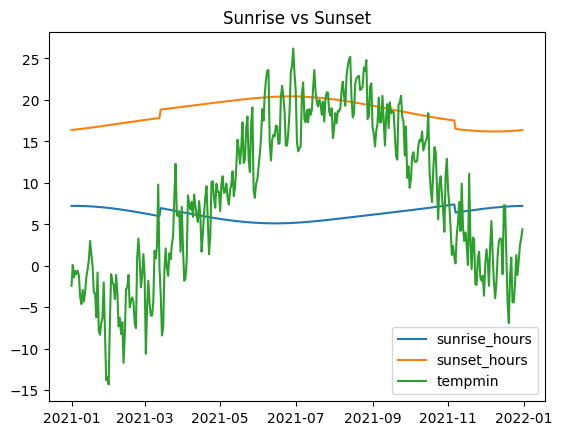

In [12]:
# Your Solution

# print(df_weather.head(5))
def hours_extract(column_name):
    '''Converts specified date columns to their respective hour translation'''
    dt = pd.to_datetime(column_name)

    hours = dt.hour
    minutes = dt.minute
    seconds = dt.second

    hour_convert = float(hours + (minutes / 60) + (seconds / 3600))
    return hour_convert

df_weather['sunrise_hours'] = df_weather['sunrise'].apply(hours_extract)
df_weather['sunset_hours'] = df_weather['sunset'].apply(hours_extract)

df_weather_hours = df_weather[['sunrise_hours', 'sunset_hours', 'tempmin']]
df_weather_hours
plt.plot(df_weather_hours)
plt.title('Sunrise vs Sunset')
plt.legend(df_weather_hours.columns)
plt.show()



**Problem 11**

**Concept:** *descriptive statistics*


**Task:**


Using `df_stock_prices`:
* Print the first 5 rows
* Display descriptive statistics

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_stock_prices_head`
* `df_stock_prices_descriptive_statistics`

**Sample Output:**


If the following was your dataframe:
```
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400
```
The following will be your output:
```
SHOW FIRST 5 ROWS:
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400

DESCRIPTIVE STATISTICS:
       units_sold     revenue
count    5.000000    5.000000
mean    15.000000  300.000000
std      4.123106   82.462113
min     10.000000  200.000000
25%     12.000000  240.000000
50%     15.000000  300.000000
75%     18.000000  360.000000
max     20.000000  400.000000
```

In [68]:
# Your Solution
df_stock_prices_head = df_stock_prices.head(5)
df_stock_prices_descriptive_statistics = df_stock_prices.describe()

print(df_stock_prices_head)
print(df_stock_prices_descriptive_statistics)




                    formatted_date        date        high         low  \
date                                                                     
2025-01-02 14:30:00     2025-01-02  1735828200  591.130005  580.500000   
2025-01-03 14:30:00     2025-01-03  1735914600  592.599976  586.429993   
2025-01-06 14:30:00     2025-01-06  1736173800  599.700012  593.599976   
2025-01-07 14:30:00     2025-01-07  1736260200  597.750000  586.780029   
2025-01-08 14:30:00     2025-01-08  1736346600  590.580017  585.200012   

                           open       close    volume    adjclose     range  
date                                                                         
2025-01-02 14:30:00  589.390015  584.640015  50204000  577.854126 -4.750000  
2025-01-03 14:30:00  587.530029  591.950012  37888500  585.079285  4.419983  
2025-01-06 14:30:00  596.270020  595.359985  47679400  588.449707 -0.910034  
2025-01-07 14:30:00  597.419983  588.630005  60393100  581.797791 -8.789978  
2025-01-08 14

**Problem 12**

**Concept:** *line graph (time series)*


**Task:**

Using `df_stock_prices`:
* Plot the `adjclose` column
* Add a title
* Display the plot


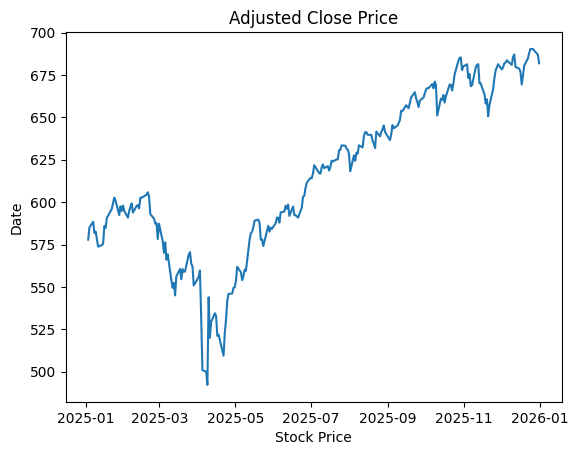

In [14]:
# Your Solution

adjclose_data = df_stock_prices['adjclose']

plt.plot(adjclose_data)
plt.title('Adjusted Close Price')
plt.xlabel('Stock Price')
plt.ylabel('Date')
plt.show()


**Problem 13**

**Concept:** *histogram*


**Task:**

Using `df_stock_prices`:
* Create a histogram of `adjclose`
* Use 25 bins
* Add a title
* Display the plot


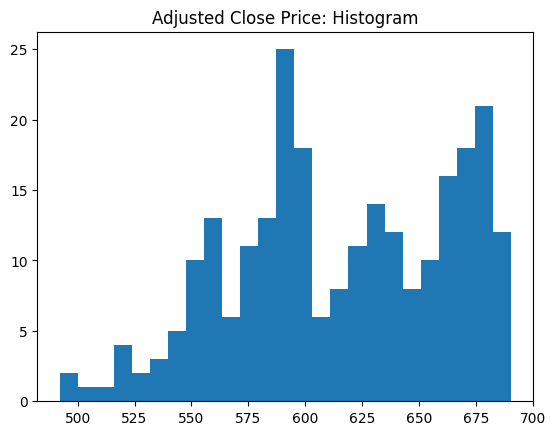

In [15]:
# Your Solution

plt.hist(adjclose_data, bins = 25)
plt.title('Adjusted Close Price: Histogram')
plt.show()




**Problem 14**

**Concept:** *Creating new column.*


**Task:**

Write a function `add_range_column(df, col_a, col_b)` that:
* Creates a new column `"range"` equal to `col_a - col_b`
* Returns the updated DataFrame

**Sample Output:**

If the following was your dataframe before adding the new column:
```
   price  discount
P1     20         2
P2     35         5
P3     15         1
P4     60        10
P5     50         8
```
The following will be your output after creating the `"range"` column:
```
   price  discount  range
P1     20         2     18
P2     35         5     30
P3     15         1     14
P4     60        10     50
P5     50         8     42
```

In [ ]:
# Your Solution

def add_range_column(df, col_a, col_b):
    '''Returns the provided dataframe with a new columns showing the range of the specified columns'''
    df['range'] = df[col_a] - df[col_b]
    return df




Test cases for problem 14

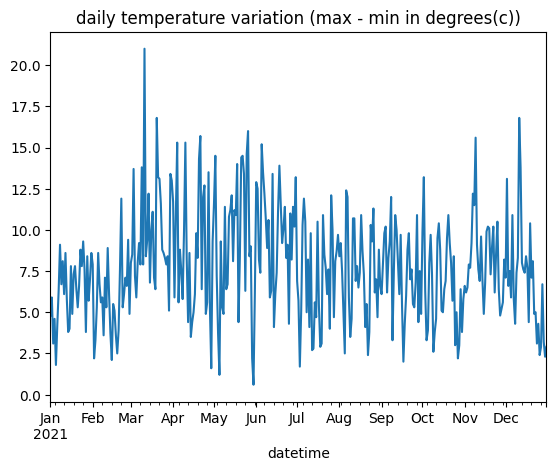

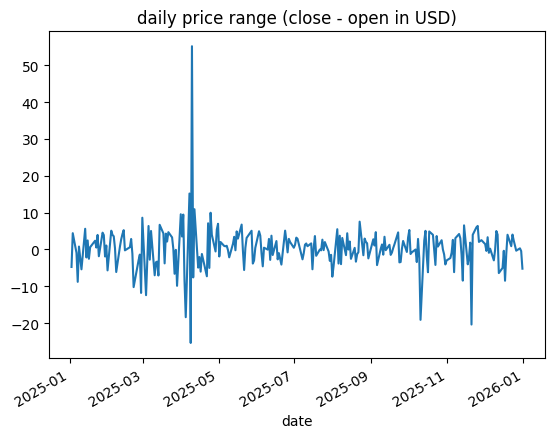

In [17]:
# test cases
df_result = add_range_column(df_weather, "tempmax", "tempmin")
df_result['range'].plot(title="daily temperature variation (max - min in degrees(c))")
plt.show()

df_result = add_range_column(df_stock_prices, "close", "open")
df_result['range'].plot(title="daily price range (close - open in USD)")
plt.show()




**Problem 15**

**Concept:** *Filtering `DataFrame` with boolean conditions*


**Task:**


Write a function `filter_rows_matching_pattern(df, column, pattern)` that:
* Returns rows where the specified column contains the given pattern
* Handles missing values
* Prints the number of matching rows

**Sample Output:**

If your selected column contained matching text values, the following could be your output:
```
Found 1 records of color containing blue.
Found 1 records of product containing hat.
Found 1 records of color containing red.
```

In [ ]:
# Your Solution

def filter_rows_matching_pattern(df, column, pattern):
    '''Returns a new dataframe that is filtered given a pattern to recognize'''
    if column not in df.columns:
        raise ValueError(f'{column} not found in {df}')
    
    df_filter = df[column].astype(str).str.contains(pattern, na=False)
    return df[df_filter]


Test cases for problem 15

In [22]:
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Snow")
# print(df_result.head())
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Overcast")
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Clear")
print(df_result.head())


           datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
datetime                                                                  
2021-01-08   1/8/21      5.3     -3.8  -0.3           2.7          -8.8   
2021-01-24  1/24/21     -0.5     -8.3  -4.9          -8.1         -17.4   
2021-01-30  1/30/21     -6.4    -13.4 -10.2         -12.9         -21.8   
2021-02-21  2/21/21      0.7     -6.9  -3.4          -1.8         -13.8   
2021-03-20  3/20/21     15.6     -1.2   6.9          15.6          -4.3   

            feelslike   dew  humidity  precip  ...              sunrise  \
datetime                                       ...                        
2021-01-08       -4.9  -9.7      51.4     0.0  ...  2021-01-08T07:13:17   
2021-01-24      -13.1 -17.2      38.7     0.0  ...  2021-01-24T07:05:07   
2021-01-30      -18.1 -18.5      51.4     0.0  ...  2021-01-30T06:59:45   
2021-02-21       -8.3 -12.4      51.0     0.0  ...  2021-02-21T06:31:47   
2021-03-20        5.4 -1

**Problem 16**

**Concept:** *Creating new DataFrame with categorical data.*


**Task:**

Write a function `create_df_categorical(df_source, column_name)` that:
* Creates a new DataFrame with:
  * counts of each category
  * percentage of each category
* Returns the new DataFrame

**Sample Output:**

If the following was one of your categorical columns:
```
blue, black, red, green, white
```
The following will be your output:
```
       count  pct
blue       1  0.2
black      1  0.2
red        1  0.2
green      1  0.2
white      1  0.2
```
If another categorical column contained:
```
summer, winter, summer, spring, winter
```
The following will be your output:
```
        count  pct
summer      2  0.4
winter      2  0.4
spring      1  0.2
```

In [78]:
# Your Solution

def create_df_categorical(df_source, column_name):
    '''Returns a new dataframe that shows the count and percentage of variables in a specified column'''
    count = df_source[column_name].value_counts()
    pct = ((count / len(df_source)))
    new_df = pd.DataFrame({
        'count': count.values,
        'pct': pct.values
    },index = count.index)
    return new_df

Test cases for problem 16

In [79]:
# test cases:
# 1: show categories of conditions
df_result = create_df_categorical(df_weather, "conditions")
print("CONDITIONS:")
print(df_result)
# 2: show categories of description
df_result = create_df_categorical(df_weather, "description")
print("DESCRIPTION:")
print(df_result)
# 3: show categories of UV index
df_result = create_df_categorical(df_weather, "uvindex")
print("UV INDEX")
print(df_result)

CONDITIONS:
                              count       pct
conditions                                   
Partially cloudy                181  0.495890
Rain, Partially cloudy           89  0.243836
Rain, Overcast                   47  0.128767
Snow, Rain, Overcast             18  0.049315
Clear                            12  0.032877
Overcast                          9  0.024658
Snow, Rain, Partially cloudy      7  0.019178
Snow, Overcast                    1  0.002740
Snow, Partially cloudy            1  0.002740
DESCRIPTION:
                                                    count       pct
description                                                        
Partly cloudy throughout the day.                     154  0.421918
Partly cloudy throughout the day with late afte...     21  0.057534
Becoming cloudy in the afternoon.                      20  0.054795
Cloudy skies throughout the day with a chance o...     18  0.049315
Partly cloudy throughout the day with rain.            15  0.

**Problem 17**

**Concept:** *Filtering records by category.*


**Task:**

Write a function `filter_weather(df, conditions, temp_min, temp_max)` that:
* Filters rows where:
  * conditions contain the given string
  * `tempmax` ≤ `temp_max`
  * `tempmin` ≥ `temp_min`
* Prints intermediate counts
* Returns the filtered DataFrame

**Sample Output:**

If your data matched the filtering conditions step by step, the following could be your output:
```
4 records with conditions Blue
3 records with conditions Blue and tempmax <= 50
2 records with conditions Blue and 20 <= temp <= 50
Found 2 records with conditions of Blue and temp between 20 and 50.
```

In [44]:
# Your Solution

def filter_weather(df, conditions, temp_min, temp_max):
    ''''Filters a weather dataframe given the conditions, maximum and minimum temperatures to be aware of'''
    df_filtered = df[df['conditions'].str.contains(conditions, na = False)]
    df_filtered = df_filtered[df_filtered['tempmin'] >= temp_min]
    df_filtered = df_filtered[df_filtered['tempmax']<= temp_max]
    return df_filtered



Test cases for problem 17

In [45]:
# looking for perfect running days:
df_result = filter_weather(df_weather, "Partially cloudy", 4, 15)
print(f"The best running days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])
print()

# looking for perfect beach days:
df_result = filter_weather(df_weather, "Clear", 5, 30)
print(f"The best beach days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])



The best running days were:
            tempmin  tempmax              conditions
datetime                                            
2021-03-27      6.1     14.0        Partially cloudy
2021-03-29      6.5     11.6  Rain, Partially cloudy
2021-04-05      8.5     14.1        Partially cloudy
2021-04-07      6.8     14.3        Partially cloudy
2021-04-08      7.7     13.5        Partially cloudy
2021-04-13      5.3     13.9        Partially cloudy
2021-04-14      7.8     11.3        Partially cloudy
2021-04-26      8.2     13.8        Partially cloudy
2021-05-07      8.2     13.5        Partially cloudy
2021-05-08      7.4     12.3        Partially cloudy
2021-10-24      5.6     14.0        Partially cloudy
2021-10-28      6.6      9.6        Partially cloudy
2021-10-29      4.1     10.5        Partially cloudy
2021-11-02      7.3     13.5        Partially cloudy
2021-11-03      4.6     11.1        Partially cloudy
2021-11-11      4.2     11.8        Partially cloudy
2021-11-13      4.

**Problem 18**

**Concept:** *Creating DataFrame, standardizing values.*


**Task:**

Write a function `create_standardized_values(df_source, columns, row_index=None)` that:
* Creates a new DataFrame
* Standardizes values relative to a given row
* Uses the first row if none is provided
* Returns the new DataFrame

**Sample Output:**

If the following was your dataframe:
```
      high_value  low_value
2020        100        50
2021        120        55
2022        140        60
2023        160        70
2024        180        75
```
If you call the function
`create_standardized_values(df_example, ["high_value", "low_value"], 2020)`,
you should get the following as the output:
```
      high_value  low_value
2020         1.0       1.00
2021         1.2       1.10
2022         1.4       1.20
2023         1.6       1.40
2024         1.8       1.50

```

In [48]:
# Your Solution

def create_standardized_values(df_source, columns, row_index = None):
    '''Creates a new DataFrame  that standardizes the values relative to a given row'''
    if row_index is None:
        row_index = 0
    if row_index >= len(df_source):
        raise ValueError(f"row_index {row_index} is out of bounds. DataFrame has {len(df_source)} rows.")
    df_standardized = df_source[columns].copy()
    base = df_source[columns].iloc[row_index]
    df_standardized = df_standardized / base
    return df_standardized

    


Test cases for problem 18

In [52]:
# test cases

# # show open/close prices relative to first item (row_index = None)
# df_result = create_standardized_values(df_stock_prices, ["open", "close"])
# df_result.plot()

# show values relative to year 2000
df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["GDP", "MedianHouse"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20", "MedianHouse"], 2000)
df_result.plot()

ValueError: row_index 2000 is out of bounds. DataFrame has 96 rows.